In [6]:
import pandas as pd

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

# Check shape
print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

# Preview
print(matches.head())
print(deliveries.head())

Matches: (1095, 20)
Deliveries: (260920, 17)
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                 

In [7]:
print("Matches missing values:")
print(matches.isnull().sum())

print("\nDeliveries missing values:")
print(deliveries.isnull().sum())

Matches missing values:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Deliveries missing values:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251

In [8]:
# Drop irrelevant columns
matches.drop(columns=['umpire1', 'umpire2', 'umpire3'], inplace=True, errors='ignore')

# Normalize team names (teams renamed over the years)
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Punjab Kings': 'Kings XI Punjab',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

matches['team1'] = matches['team1'].replace(team_name_map)
matches['team2'] = matches['team2'].replace(team_name_map)
matches['winner'] = matches['winner'].replace(team_name_map)
matches['toss_winner'] = matches['toss_winner'].replace(team_name_map)

# Convert date to datetime
matches['date'] = pd.to_datetime(matches['date'])

# Extract season/year
matches['season'] = matches['date'].dt.year

print(matches.shape)
print(matches.dtypes)

(1095, 18)
id                          int64
season                      int32
city                          str
date               datetime64[us]
match_type                    str
player_of_match               str
venue                         str
team1                         str
team2                         str
toss_winner                   str
toss_decision                 str
winner                        str
result                        str
result_margin             float64
target_runs               float64
target_overs              float64
super_over                    str
method                        str
dtype: object


In [9]:
# Check for nulls in key columns
print(deliveries[['batsman_runs', 'total_runs', 'player_dismissed']].isnull().sum())

# Fill missing player_dismissed with 'not out'
deliveries['player_dismissed'].fillna('not out', inplace=True)

# Remove wide and no-ball deliveries for certain analyses
legal_deliveries = deliveries[(deliveries['wide_runs'] == 0) & (deliveries['noball_runs'] == 0)]

print("Total deliveries:", len(deliveries))
print("Legal deliveries:", len(legal_deliveries))

batsman_runs             0
total_runs               0
player_dismissed    247970
dtype: int64


C:\Users\vinay\AppData\Local\Temp\ipykernel_21528\2369746547.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  deliveries['player_dismissed'].fillna('not out', inplace=True)


KeyError: 'wide_runs'

In [10]:
print(deliveries.columns.tolist())


['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [11]:
# Check for nulls in key columns
print(deliveries[['batsman_runs', 'total_runs', 'player_dismissed']].isnull().sum())

# Fill missing player_dismissed with 'not out'
deliveries['player_dismissed'].fillna('not out', inplace=True)

# Remove wide and no-ball deliveries using extras_type
legal_deliveries = deliveries[~deliveries['extras_type'].isin(['wides', 'noballs'])]

print("Total deliveries:", len(deliveries))
print("Legal deliveries:", len(legal_deliveries))


batsman_runs             0
total_runs               0
player_dismissed    247970
dtype: int64
Total deliveries: 260920
Legal deliveries: 251471


C:\Users\vinay\AppData\Local\Temp\ipykernel_21528\3926739647.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  deliveries['player_dismissed'].fillna('not out', inplace=True)


In [12]:
# Merge deliveries with match info for richer analysis
merged = deliveries.merge(matches[['id', 'season', 'venue', 'winner', 'toss_winner', 'toss_decision']], 
                          left_on='match_id', right_on='id')

print(merged.shape)
print(merged.head())

(260920, 23)
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  ...  is_wicket  \
0     1   SC Ganguly  P Kumar  BB McCullum             0  ...          0   
1     2  BB McCullum  P Kumar   SC Ganguly             0  ...          0   
2     3  BB McCullum  P Kumar   SC Ganguly             0  ...          0   
3     4  BB McCullum  P Kumar   SC Ganguly             0  ...          0   
4     5  BB McCullum  P Kumar   SC Ganguly             0  ...          0   

   player_dismissed dismissal_kind  fielder

In [13]:
matches.to_csv("matches_cleaned.csv", index=False)
deliveries.to_csv("deliveries_cleaned.csv", index=False)
merged.to_csv("merged_data.csv", index=False)

print("✅ Cleaned files saved!")

✅ Cleaned files saved!


C:\Users\vinay\AppData\Local\Temp\ipykernel_21528\592786907.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_wins, x='wins', y='team', palette='viridis')


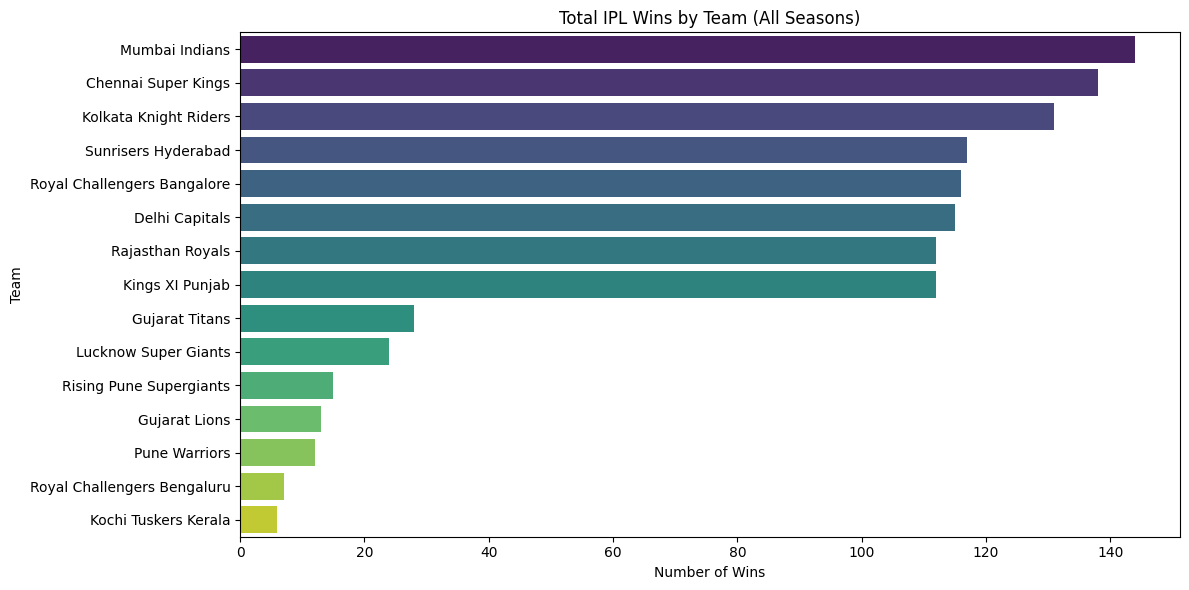

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total wins per team across all seasons
team_wins = matches['winner'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']

plt.figure(figsize=(12, 6))
sns.barplot(data=team_wins, x='wins', y='team', palette='viridis')
plt.title('Total IPL Wins by Team (All Seasons)')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('team_wins.png')
plt.show()

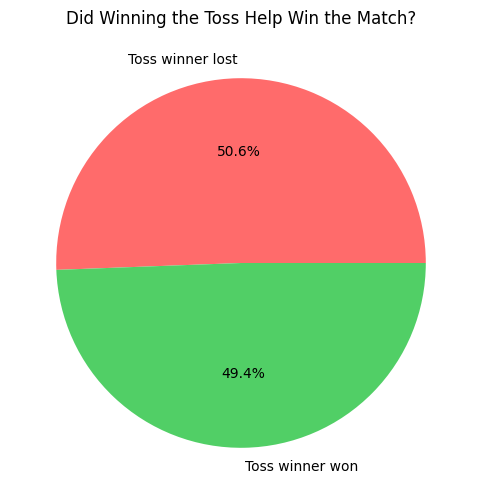

toss_decision
field    704
bat      391
Name: count, dtype: int64


In [17]:
# Did winning the toss help win the match?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_impact = matches['toss_match_winner'].value_counts()
labels = ['Toss winner lost', 'Toss winner won']

plt.figure(figsize=(6, 6))
plt.pie(toss_impact, labels=labels, autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'])
plt.title('Did Winning the Toss Help Win the Match?')
plt.savefig('toss_impact.png')
plt.show()

# Toss decision breakdown
toss_decision = matches['toss_decision'].value_counts()
print(toss_decision)

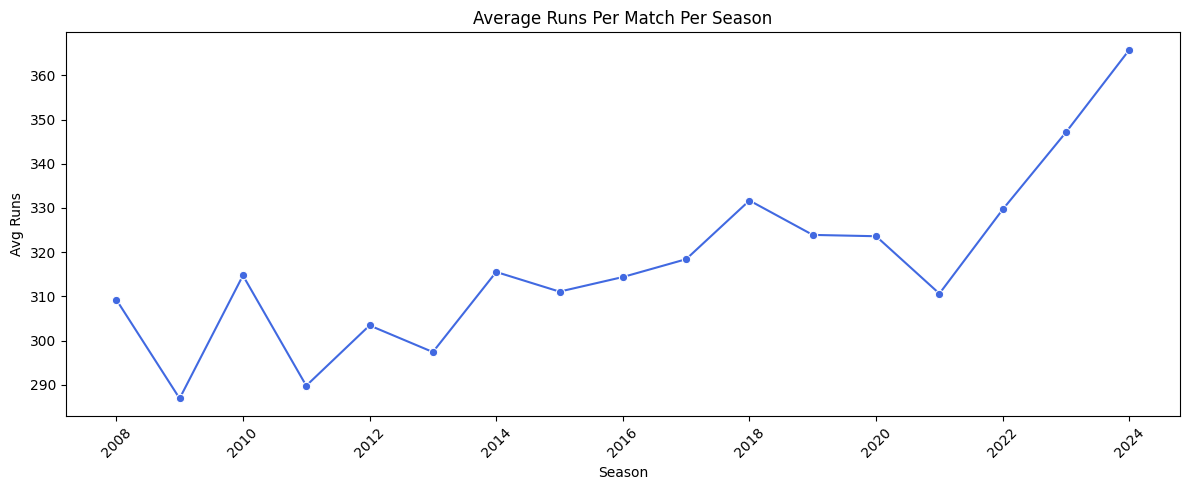

In [18]:
# Average runs per match per season
season_runs = merged.groupby('season')['total_runs'].sum()
matches_per_season = matches.groupby('season')['id'].count()
avg_runs = (season_runs / matches_per_season).reset_index()
avg_runs.columns = ['season', 'avg_runs']

plt.figure(figsize=(12, 5))
sns.lineplot(data=avg_runs, x='season', y='avg_runs', marker='o', color='royalblue')
plt.title('Average Runs Per Match Per Season')
plt.xlabel('Season')
plt.ylabel('Avg Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('season_runs_trend.png')
plt.show()

C:\Users\vinay\AppData\Local\Temp\ipykernel_21528\1931607759.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='magma')


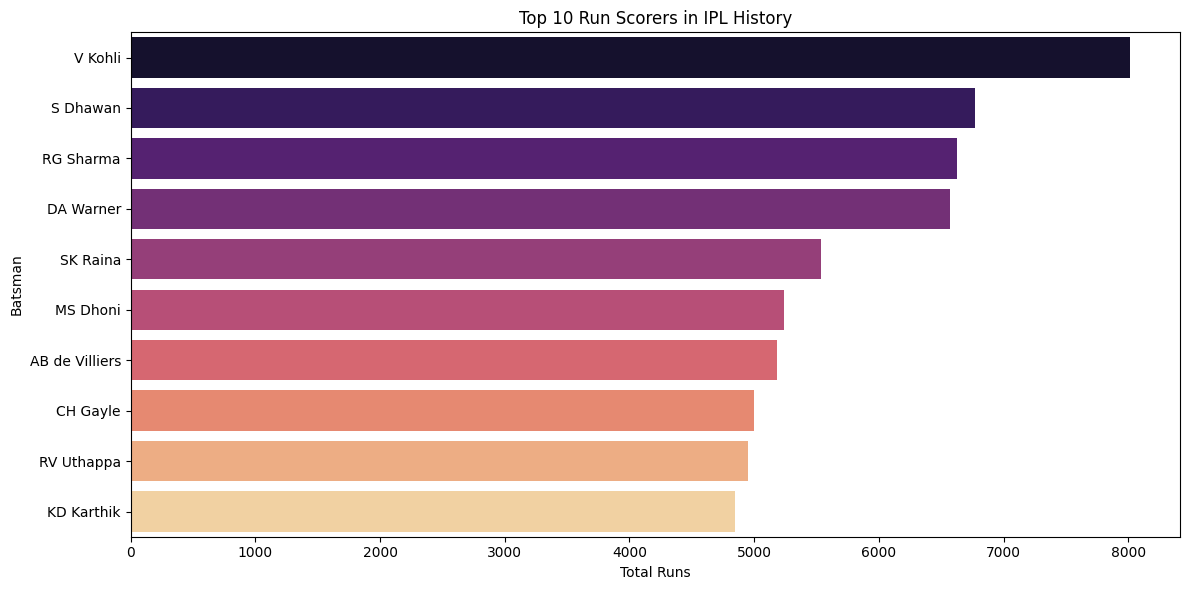

C:\Users\vinay\AppData\Local\Temp\ipykernel_21528\1931607759.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='rocket')


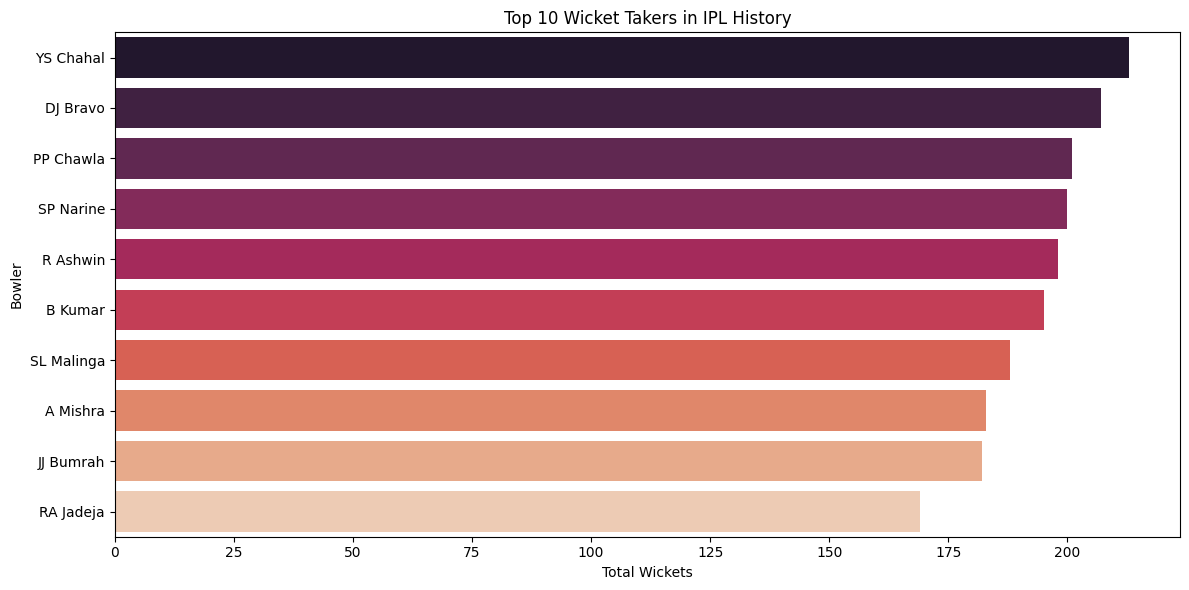

In [19]:
# Top 10 run scorers all time
top_batsmen = merged.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='magma')
plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('top_batsmen.png')
plt.show()

# Top 10 wicket takers
top_bowlers = merged[merged['is_wicket'] == 1].groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='rocket')
plt.title('Top 10 Wicket Takers in IPL History')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('top_bowlers.png')
plt.show()


In [20]:
import sqlite3
import pandas as pd

# Connect to (or create) the database
conn = sqlite3.connect('ipl.db')

# Load cleaned CSVs
matches = pd.read_csv("matches_cleaned.csv")
deliveries = pd.read_csv("deliveries_cleaned.csv")
merged = pd.read_csv("merged_data.csv")

# Write to SQL tables
matches.to_sql('matches', conn, if_exists='replace', index=False)
deliveries.to_sql('deliveries', conn, if_exists='replace', index=False)
merged.to_sql('merged', conn, if_exists='replace', index=False)

print("✅ Data loaded into ipl.db successfully!")

✅ Data loaded into ipl.db successfully!


In [21]:
cursor = conn.cursor()

# List all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables:", cursor.fetchall())

# Preview matches table
print(pd.read_sql("SELECT * FROM matches LIMIT 5", conn))

Tables: [('matches',), ('deliveries',), ('merged',)]
       id  season        city        date match_type player_of_match  \
0  335982    2008   Bangalore  2008-04-18     League     BB McCullum   
1  335983    2008  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984    2008       Delhi  2008-04-19     League     MF Maharoof   
3  335985    2008      Mumbai  2008-04-20     League      MV Boucher   
4  335986    2008     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla               Delhi Capitals   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2               

In [22]:
q1 = pd.read_sql("""
    SELECT winner AS team, COUNT(*) AS total_wins
    FROM matches
    WHERE winner IS NOT NULL
    GROUP BY winner
    ORDER BY total_wins DESC
""", conn)
print(q1)

                           team  total_wins
0                Mumbai Indians         144
1           Chennai Super Kings         138
2         Kolkata Knight Riders         131
3           Sunrisers Hyderabad         117
4   Royal Challengers Bangalore         116
5                Delhi Capitals         115
6              Rajasthan Royals         112
7               Kings XI Punjab         112
8                Gujarat Titans          28
9          Lucknow Super Giants          24
10      Rising Pune Supergiants          15
11                Gujarat Lions          13
12                Pune Warriors          12
13  Royal Challengers Bengaluru           7
14         Kochi Tuskers Kerala           6


In [23]:
q2 = pd.read_sql("""
    SELECT season, COUNT(*) AS total_matches
    FROM matches
    GROUP BY season
    ORDER BY season
""", conn)
print(q2)

    season  total_matches
0     2008             58
1     2009             57
2     2010             60
3     2011             73
4     2012             74
5     2013             76
6     2014             60
7     2015             59
8     2016             60
9     2017             59
10    2018             60
11    2019             60
12    2020             60
13    2021             60
14    2022             74
15    2023             74
16    2024             71


In [24]:
q3 = pd.read_sql("""
    SELECT season, toss_decision, COUNT(*) AS count
    FROM matches
    GROUP BY season, toss_decision
    ORDER BY season
""", conn)
print(q3)

    season toss_decision  count
0     2008           bat     26
1     2008         field     32
2     2009           bat     35
3     2009         field     22
4     2010           bat     39
5     2010         field     21
6     2011           bat     25
7     2011         field     48
8     2012           bat     37
9     2012         field     37
10    2013           bat     45
11    2013         field     31
12    2014           bat     19
13    2014         field     41
14    2015           bat     25
15    2015         field     34
16    2016           bat     11
17    2016         field     49
18    2017           bat     11
19    2017         field     48
20    2018           bat     10
21    2018         field     50
22    2019           bat     10
23    2019         field     50
24    2020           bat     27
25    2020         field     33
26    2021           bat     16
27    2021         field     44
28    2022           bat     15
29    2022         field     59
30    20

In [25]:
q4 = pd.read_sql("""
    SELECT batter, SUM(batsman_runs) AS total_runs
    FROM deliveries
    GROUP BY batter
    ORDER BY total_runs DESC
    LIMIT 10
""", conn)
print(q4)

           batter  total_runs
0         V Kohli        8014
1        S Dhawan        6769
2       RG Sharma        6630
3       DA Warner        6567
4        SK Raina        5536
5        MS Dhoni        5243
6  AB de Villiers        5181
7        CH Gayle        4997
8      RV Uthappa        4954
9      KD Karthik        4843


In [26]:
q5 = pd.read_sql("""
    SELECT bowler, COUNT(*) AS total_wickets
    FROM deliveries
    WHERE is_wicket = 1
    GROUP BY bowler
    ORDER BY total_wickets DESC
    LIMIT 10
""", conn)
print(q5)

       bowler  total_wickets
0   YS Chahal            213
1    DJ Bravo            207
2   PP Chawla            201
3   SP Narine            200
4    R Ashwin            198
5     B Kumar            195
6  SL Malinga            188
7    A Mishra            183
8   JJ Bumrah            182
9   RA Jadeja            169


In [27]:
q6 = pd.read_sql("""
    SELECT venue, COUNT(*) AS matches_played
    FROM matches
    GROUP BY venue
    ORDER BY matches_played DESC
    LIMIT 10
""", conn)
print(q6)

                                        venue  matches_played
0                                Eden Gardens              77
1                            Wankhede Stadium              73
2                       M Chinnaswamy Stadium              65
3                            Feroz Shah Kotla              60
4   Rajiv Gandhi International Stadium, Uppal              49
5             MA Chidambaram Stadium, Chepauk              48
6                      Sawai Mansingh Stadium              47
7         Dubai International Cricket Stadium              46
8                    Wankhede Stadium, Mumbai              45
9  Punjab Cricket Association Stadium, Mohali              35


In [28]:
q1.to_csv("sql_team_wins.csv", index=False)
q4.to_csv("sql_top_batsmen.csv", index=False)
q5.to_csv("sql_top_bowlers.csv", index=False)

print("✅ Query results saved!")

# Close connection
conn.close()

✅ Query results saved!


In [29]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('ipl.db')

# Export all key tables
pd.read_sql("SELECT * FROM matches", conn).to_csv("tableau_matches.csv", index=False)
pd.read_sql("SELECT * FROM deliveries", conn).to_csv("tableau_deliveries.csv", index=False)
pd.read_sql("SELECT * FROM merged", conn).to_csv("tableau_merged.csv", index=False)

# Export query results
pd.read_sql("""
    SELECT winner AS team, COUNT(*) AS total_wins
    FROM matches WHERE winner IS NOT NULL
    GROUP BY winner ORDER BY total_wins DESC
""", conn).to_csv("tableau_team_wins.csv", index=False)

pd.read_sql("""
    SELECT batter, SUM(batsman_runs) AS total_runs
    FROM deliveries GROUP BY batter
    ORDER BY total_runs DESC LIMIT 10
""", conn).to_csv("tableau_top_batsmen.csv", index=False)

pd.read_sql("""
    SELECT bowler, COUNT(*) AS total_wickets
    FROM deliveries WHERE is_wicket = 1
    GROUP BY bowler ORDER BY total_wickets DESC LIMIT 10
""", conn).to_csv("tableau_top_bowlers.csv", index=False)

pd.read_sql("""
    SELECT season, toss_decision, COUNT(*) AS count
    FROM matches GROUP BY season, toss_decision
""", conn).to_csv("tableau_toss_trends.csv", index=False)

pd.read_sql("""
    SELECT venue, COUNT(*) AS matches_played
    FROM matches GROUP BY venue
    ORDER BY matches_played DESC LIMIT 10
""", conn).to_csv("tableau_venues.csv", index=False)

conn.close()
print("✅ All Tableau files exported!")

✅ All Tableau files exported!


In [30]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('ipl.db')

# Top batsmen by season
pd.read_sql("""
    SELECT season, batter, SUM(batsman_runs) AS total_runs
    FROM merged
    GROUP BY season, batter
    ORDER BY total_runs DESC
""", conn).to_csv("tableau_top_batsmen.csv", index=False)

# Top bowlers by season
pd.read_sql("""
    SELECT season, bowler, COUNT(*) AS total_wickets
    FROM merged
    WHERE is_wicket = 1
    GROUP BY season, bowler
    ORDER BY total_wickets DESC
""", conn).to_csv("tableau_top_bowlers.csv", index=False)

# Team wins by season
pd.read_sql("""
    SELECT season, winner AS team, COUNT(*) AS total_wins
    FROM matches
    WHERE winner IS NOT NULL
    GROUP BY season, winner
    ORDER BY total_wins DESC
""", conn).to_csv("tableau_team_wins.csv", index=False)

# Venues by season
pd.read_sql("""
    SELECT season, venue, COUNT(*) AS matches_played
    FROM matches
    GROUP BY season, venue
    ORDER BY matches_played DESC
""", conn).to_csv("tableau_venues.csv", index=False)

conn.close()
print("✅ Updated CSVs exported!")

✅ Updated CSVs exported!
